In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [2]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

EXP_NAME = "echem_exp"
ROOT = Path("../sample_datasets/20221014_experiments/echem")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

psd = pd.read_csv(PSD_PATH, header=None)
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]

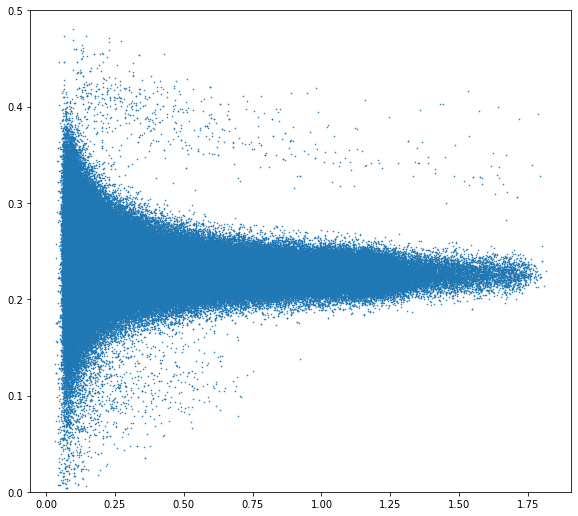

In [3]:
# Plot PSD
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
ax.set_ylim(0,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

# Converting Voltage to Light Output

In [4]:
def v_to_l(voltage):
    V1 = 205 * 1e-3
    L1 = 900 * 1e-3
    V2 = 290 * 1e-3
    L2 = 1200 * 1e-3

    m = (L2-L1) / (V2-V1)
    b =  L1 - m * V1
    return m * voltage + b

psd_report["energy"] = psd_report["amplitude"].apply(v_to_l)

(0.0, 0.5)

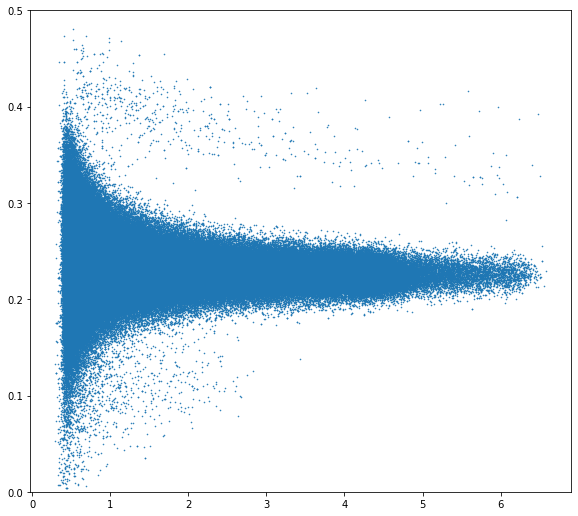

In [5]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.5)

(0.0, 0.45)

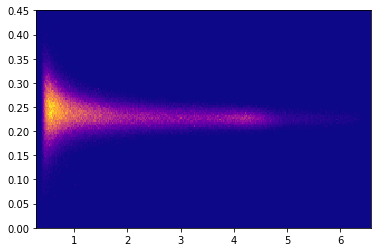

In [6]:
x, y = psd_report["energy"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_e = xe[-2]
cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
plt.ylim(0,0.45)

In [7]:
def sigma_slice(ye, counts, idx, lb, ub):
    return curve_fit(
        gaussian,
        ye[:-1], 
        counts[:,idx],
        bounds=(lb,ub)
    )


def get_gamma_bound_point(xe, ye, counts, idx, lb=(0.22,0.001,1), ub=(0.26,0.2,250)):
    energy = (xe[idx] + xe[idx + 1]) / 2
    (mu, sigma, A), cov = sigma_slice(ye, counts, idx, lb, ub)
    
    return energy, mu, sigma
    

counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
for idx in range(min_i, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx)
    energy.append(e)
    sigma.append(s)
    mu.append(m)

In [8]:
from scipy.signal import savgol_filter

f_sigma = savgol_filter(sigma, 21, 3)
f_mu = savgol_filter(mu, 21, 3)

lower_bound = []
upper_bound = []
for s, m in zip(sigma,mu):
    lower_bound.append(m + 4*s)

offset = 0.2
f_lb = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9))

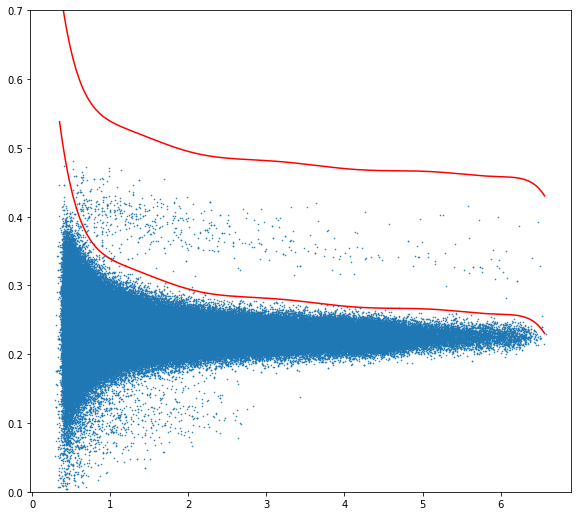

In [9]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.7)

ax.plot(xe[min_i:-1], f_lb(xe[min_i:-1]), 'r-')
ax.plot(xe[min_i:-1], f_lb(xe[min_i:-1]) + offset, 'r-')

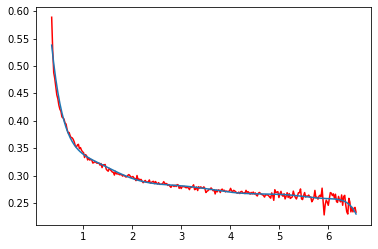

In [10]:
xe_r = np.linspace(0, xe[-1], 200)
plt.plot(xe[3:-1], lower_bound, 'r-')
plt.plot(xe[min_i:-1], f_lb(xe[min_i:-1]))

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



In [11]:
def lo_output(Ep):
    return 0.748*Ep-2.41*(1-np.exp(-0.298*Ep))

L1, L2, L3 = lo_output(np.array([2.5, 4.0, 6.0]))

L1, L2, L3

(0.604109662855189, 1.3137083652773722, 2.481179562200148)

In [12]:
def classify_plot(psd_report, xe, f_lb, cutoffs=[L1, L2, L3]):
    neutrons = psd_report[psd_report["tail / total"].between(f_lb(psd_report["energy"]), f_lb(psd_report["energy"]) + offset)]
    
    # plot distribution
    fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
    fig.set_figheight(7)
    fig.set_figwidth(8)
    ax.set_ylim(0,0.6)

    xe_r = np.linspace(xe[min_i], xe[-1], 200)

    # plot bounds
    ax.plot(xe_r, f_lb(xe_r), 'r-')
    ax.plot(xe_r, f_lb(xe_r) + offset, 'r-')

    # plot vlines
    ax.vlines(xe_r[0], f_lb(xe_r[0]), f_lb(xe_r[0]) + offset ,'r')
    ax.vlines(xe_r[-1], f_lb(xe_r[-1]), f_lb(xe_r[-1]) + offset, 'r')

    # plot neutrons
    ax.scatter(neutrons["energy"], neutrons["tail / total"], marker="o", s=3, c="orange")

    ax.set_title(f"$N={neutrons.shape[0]}$", fontsize=18)
    ax.set_ylabel("PSD")
    ax.set_xlabel("Energy (MeVee)")

    for lo in cutoffs:
        ax.vlines(lo, f_lb(lo), f_lb(lo) + offset, 'k')
    
    return fig, ax, neutrons

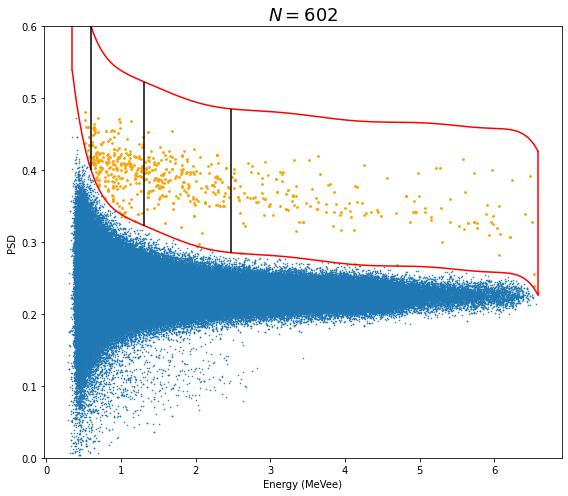

In [13]:
fig, ax, neutrons = classify_plot(psd_report, xe, f_lb)
fig.tight_layout()

# Altogether

In [14]:
EXP_NAME = "echem_exp"
ROOT = Path("../sample_datasets/20221014_experiments/")

ECHEM_ROOT = ROOT / "echem"
EPLAS_ROOT = ROOT / "echem_plasma"
PLAS_ROOT = ROOT / "plasma"

psd = pd.read_csv(EPLAS_ROOT / "PSD.csv", header=None)
amplitudes = pd.read_csv(EPLAS_ROOT / "amplitudes.csv", header=None)
eplas_df = pd.concat([psd, amplitudes], axis=1)
eplas_df.columns = ["tail / total", "amplitude"]
eplas_df["energy"] = (eplas_df["amplitude"]).apply(v_to_l)

psd = pd.read_csv(PLAS_ROOT / "PSD.csv", header=None)
amplitudes = pd.read_csv(PLAS_ROOT / "amplitudes.csv", header=None)
plas_df = pd.concat([psd, amplitudes], axis=1)
plas_df.columns = ["tail / total", "amplitude"]
plas_df = plas_df.dropna(axis=0)
plas_df["energy"] = (plas_df["amplitude"]).apply(v_to_l)

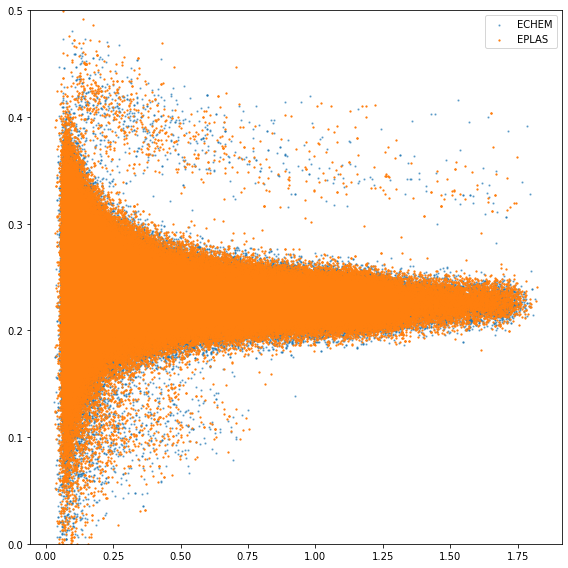

In [15]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(psd_report["amplitude"], psd_report["tail / total"], s=1.5, alpha=0.5, label="ECHEM")
ax.scatter(eplas_df["amplitude"], eplas_df["tail / total"], s=1.5, label="EPLAS")
ax.set_ylim(0,0.5)
ax.legend()
fig.tight_layout()

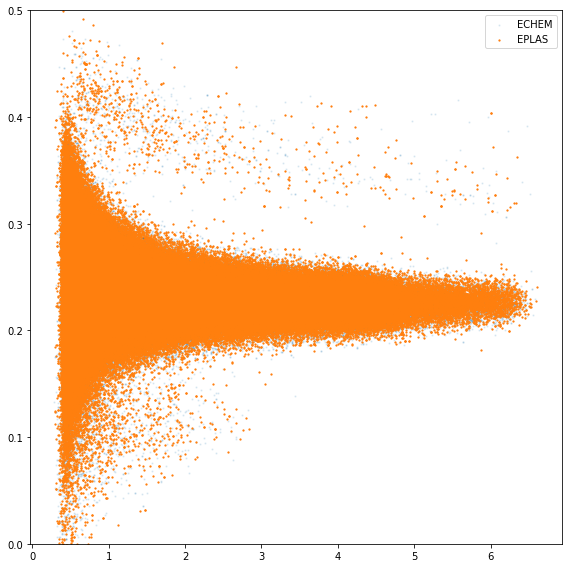

In [16]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(psd_report["energy"], psd_report["tail / total"], s=1.5, alpha=0.1, label="ECHEM")
ax.scatter(eplas_df["energy"], eplas_df["tail / total"], s=1.5, label="EPLAS")
ax.set_ylim(0,0.5)
ax.legend()
fig.tight_layout()

# EChem + Plasma

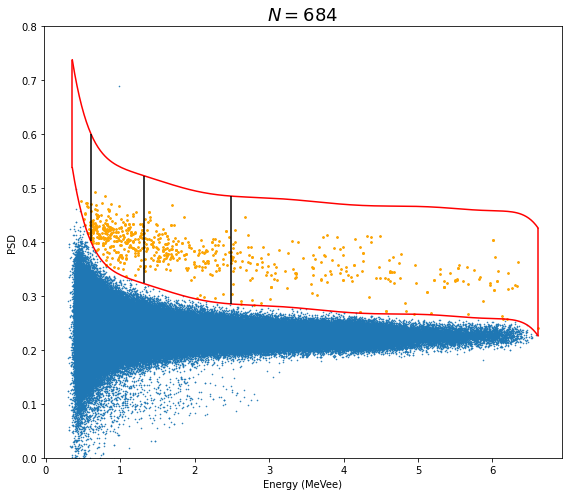

In [17]:
x, y = eplas_df["energy"], eplas_df["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_ep = xe[-2]
counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
offset = 0.2
for idx in range(min_i, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx, lb=(0.2,0.001,1),ub=(0.3,0.1,300))
    energy.append(e)
    sigma.append(s)
    mu.append(m)
    
f_lb_ep = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9))

fig, ax, neutrons_ep = classify_plot(eplas_df, xe, f_lb_ep)
# ax.set_xlim(0.1, 0.8)
ax.set_ylim(0,0.8)
fig.tight_layout()

# Plasma

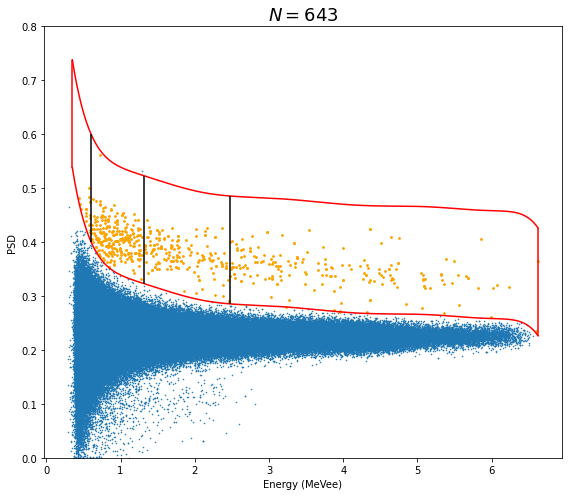

In [18]:
x, y = plas_df["energy"], plas_df["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)
L4_p = xe[-2]
counts = Z.T

energy = []
sigma = []
mu = []

min_i = 3
offset = 0.2
for idx in range(min_i, len(xe) - 1):
    # print(idx)
    e, m, s = get_gamma_bound_point(xe, ye, counts, idx, lb=(0.2,0.001,1),ub=(0.3,0.02,10_000))
    energy.append(e)
    sigma.append(s)
    mu.append(m)
    
f_lb_p = np.poly1d(np.polyfit(xe[min_i:-1], lower_bound, 9))

fig, ax, neutrons_p = classify_plot(plas_df, xe, f_lb_p)
# ax.set_xlim(0.1, 0.8)
ax.set_ylim(0,0.8)

fig.tight_layout()

# Rates

In [19]:
t = 2704.29
t_ep = 3019.74
t_p = 2793.46

# t = 2704.29
# t_ep = 2704.29
# t_p = 2704.29

def get_bounded_counts(psd, Ll, Lr):
    return psd[psd["energy"].between(Ll, Lr)].shape[0]

def get_rates_sigmas(neutrons, t, L1=L1, L2=L2, L3=L3, L4=xe_r[-1]):
    r1 = get_bounded_counts(neutrons, L1, L2) / t
    r2 = get_bounded_counts(neutrons, L2, L3) / t
    r3 = get_bounded_counts(neutrons, L3, L4) / t
    
    return [r1,r2,r3], np.sqrt(np.array([r1, r2, r3]) * t) / t

rates_e, sigmas_e = get_rates_sigmas(neutrons, t, L4=L4_e)
rates_ep, sigmas_ep = get_rates_sigmas(neutrons_ep, t_ep, L4=L4_ep)
rates_p, sigmas_p = get_rates_sigmas(neutrons_p, t_p, L4=L4_p)

# Moment of Truth

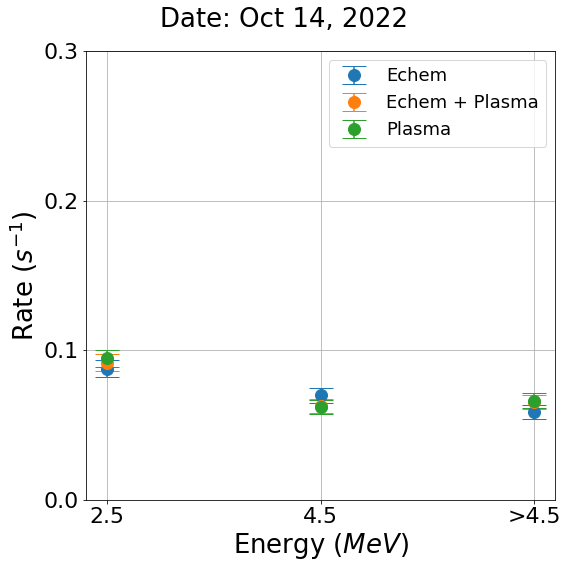

In [30]:
bins = ["2.5", "4.5", ">4.5"]

fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar(bins, rates_e, yerr=sigmas_e, fmt = "o", markersize=12, linestyle="", label="Echem", capsize=12)
ax.errorbar(bins, rates_ep, yerr=sigmas_ep, fmt = "o", markersize=12, linestyle="", label="Echem + Plasma", capsize=12)
ax.errorbar(bins, rates_p, yerr=sigmas_p, fmt = "o", markersize=12, linestyle="", label="Plasma", capsize=12)
# ax.errorbar(bins, rates_bg, yerr=sigmas_bg, fmt = "o", markersize=12, linestyle="", label="Background", capsize=8)

ax.set_ylabel("Rate $(s^{{-1}})$", fontsize=26)
ax.set_xlabel("Energy $(MeV)$", fontsize=26)
# ax.set_ylim(0.0, 0.3)
ax.set_yticks(np.arange(0,0.4,0.1))
fig.suptitle("Date: Oct 14, 2022", fontsize=26)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
ax.grid()
ax.legend(fontsize=18)
fig.tight_layout()
plt.show()

# Appendix Exploration

In [21]:
i = 25
zeta = Z.T
xe[i], zeta[:,i]

(0.815395294117647,
 array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    6.,   27.,  850., 3187.,  257.,
           6.,    4.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0., 

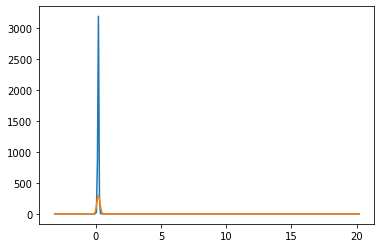

In [22]:
params, _ = curve_fit(
    gaussian,
    ye[:-1], 
    zeta[:,i],
    bounds=((0.2,0.001,1),(0.3,0.2,300))
)

plt.plot(ye[:-1], zeta[:,i])
plt.plot(ye[:-1], gaussian(ye[:-1], *params))
# plt.xlim(0.2,0.3)
# plt.yscale("log")